In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)
df.head()
print(df.info())

Saving Churn_Modelling.csv to Churn_Modelling (3).csv
(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [ ]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print(df.shape)
print(df.head())

(10000, 11)
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [ ]:
print(df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["Geography", "Gender"]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
import numpy as np

X_train_processed = np.asarray(X_train_processed)
X_test_processed = np.asarray(X_test_processed)

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (8000, 13)
X_test_processed: (2000, 13)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


In [ ]:
history = model.fit(
    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=100,
    batch_size=32,

    class_weight=class_weights,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6461 - loss: 0.6354 - precision: 0.3214 - recall: 0.6557 - val_accuracy: 0.6881 - val_loss: 0.5797 - val_precision: 0.3608 - val_recall: 0.7250
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7111 - loss: 0.5624 - precision: 0.3887 - recall: 0.7183 - val_accuracy: 0.6906 - val_loss: 0.5699 - val_precision: 0.3730 - val_recall: 0.8031
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7161 - loss: 0.5417 - precision: 0.3981 - recall: 0.7557 - val_accuracy: 0.7406 - val_loss: 0.5072 - val_precision: 0.4202 - val_recall: 0.7812
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7400 - loss: 0.5160 - precision: 0.4255 - recall: 0.7718 - val_accuracy: 0.7706 - val_loss: 0.4582 - val_precision: 0.4559 - val_recall: 0.7594
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7530 - loss: 0.5116 - precision: 0.4398 - recall: 0.7550 - val_accuracy: 0.7600 - val_los

In [ ]:
test_results = model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("Test Results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

Test Results:
loss: 0.4326
compile_metrics: 0.8005


In [ ]:
y_pred_prob = model.predict(
    X_test_processed
).ravel()

print(y_pred_prob[:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[0.08012888 0.2343622  0.12888841 0.18725336 0.2919129  0.5291071
 0.10374784 0.5727569  0.8097332  0.18972425]


In [ ]:
y_pred = (y_pred_prob >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

Accuracy : 0.8005
Precision: 0.507
Recall   : 0.7101
F1 Score : 0.5916
ROC-AUC  : 0.8551


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

   Not Churn       0.92      0.82      0.87      1593
       Churn       0.51      0.71      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.77      0.73      2000
weighted avg       0.83      0.80      0.81      2000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1312  281]
 [ 118  289]]


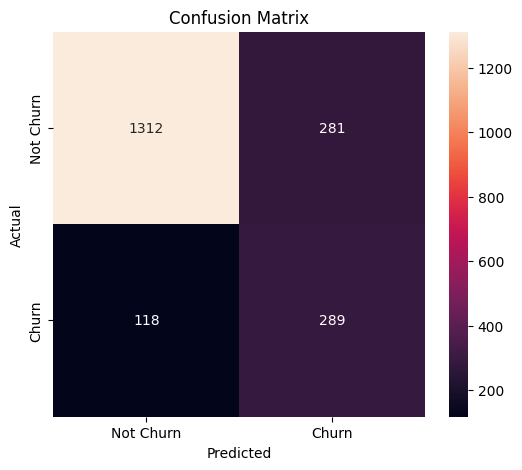

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

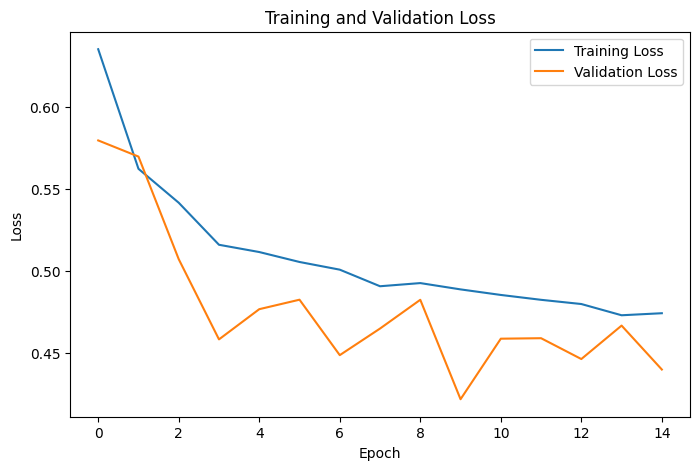

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

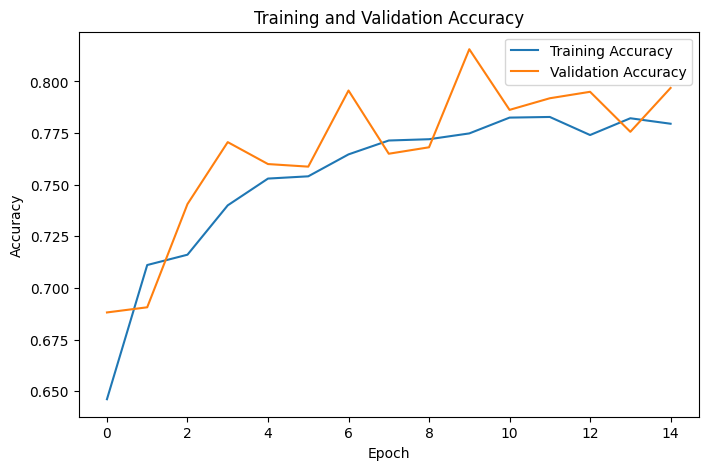

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

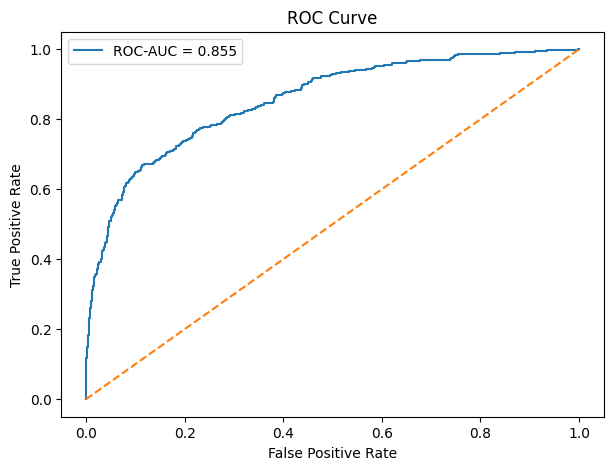

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

auc = roc_auc_score(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

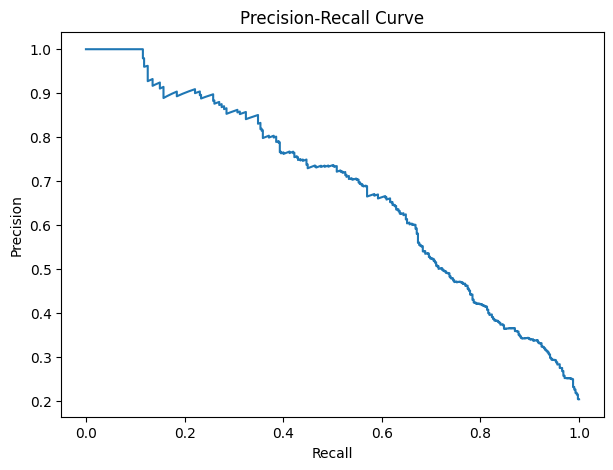

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_pred_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [ ]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds_to_test:

    predictions = (
        y_pred_prob >= threshold
    ).astype(int)

    print(
        f"\nThreshold: {threshold}"
    )

    print(
        "Precision:",
        round(precision_score(y_test, predictions), 4)
    )

    print(
        "Recall:",
        round(recall_score(y_test, predictions), 4)
    )

    print(
        "F1:",
        round(f1_score(y_test, predictions), 4)
    )


Threshold: 0.3
Precision: 0.3589
Recall: 0.8747
F1: 0.5089

Threshold: 0.4
Precision: 0.422
Recall: 0.7912
F1: 0.5504

Threshold: 0.5
Precision: 0.507
Recall: 0.7101
F1: 0.5916

Threshold: 0.6
Precision: 0.6271
Recall: 0.6364
F1: 0.6317

Threshold: 0.7
Precision: 0.7321
Recall: 0.5037
F1: 0.5968


In [ ]:
model.save("churn_ann_model.keras")

In [ ]:
import joblib

joblib.dump(
    preprocessor,
    "churn_preprocessor.pkl"
)

['churn_preprocessor.pkl']

In [ ]:
preprocessor_loaded = joblib.load(
    "churn_preprocessor.pkl"
)